<a href="https://colab.research.google.com/github/Juansesalgado/Imputaci-n-de-datos/blob/main/Imputacion_de_datos_PM2_5_y_PM10_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import holidays

data = pd.read_excel("datos_reorganizados_PMs (SIN IMPUTAR).xlsx")
data['datetime'] = pd.to_datetime(data['datetime'])

datetime_col = data['datetime']
df_numeric = data.drop(columns=['datetime'])

day_of_week = data['datetime'].dt.day_name()
is_weekend = data['datetime'].dt.weekday >= 5
colombian_holidays = holidays.country_holidays('CO')
is_holiday = data['datetime'].isin(colombian_holidays)

day_dummies = pd.get_dummies(day_of_week, prefix='day')

df_model_input = pd.concat([df_numeric, day_dummies, is_weekend, is_holiday], axis=1)
df_model_input.rename(columns={0: 'is_weekend', 1: 'is_holiday'}, inplace=True)
df_model_input['is_weekend'] = is_weekend.astype(int)
df_model_input['is_holiday'] = is_holiday.astype(int)

imp_RF = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    verbose=1,
    random_state=42
)

imp_RF.fit(df_model_input)
df_imputado_completo = pd.DataFrame(imp_RF.transform(df_model_input), columns=df_model_input.columns)

df_imp_RF = df_imputado_completo[df_numeric.columns]

df_final = pd.concat([datetime_col.reset_index(drop=True), df_imp_RF], axis=1)
df_final['day_of_week'] = day_of_week
df_final['is_weekend'] = is_weekend
df_final['is_holiday'] = is_holiday

print(df_final.head())



[IterativeImputer] Completing matrix with shape (365, 21)
[IterativeImputer] Change: 72.21656601552651, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 39.535823936884576, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 23.956138217683186, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 34.38709823338955, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 21.643910217993625, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 14.552096714232105, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 13.106615216410773, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 10.01535610110092, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 11.884388751011468, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 15.624669960204173, scaled tolerance: 0.10647752274 
[IterativeImputer] Completing matrix with shape (365, 21)


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


    datetime  PM10 CARDIQUE-RA-01  PM10 CARDIQUE-RA-02  \
0 2023-01-01            14.632223            18.488496   
1 2023-01-02            14.343267            18.909050   
2 2023-01-03            15.736043            18.765329   
3 2023-01-04            18.671171            22.027225   
4 2023-01-05            21.435097            24.186472   

   PM10 P_CTG3 - ESTACION DE CARDIQUE  PM10 P_CTG4- MAMONAL  \
0                           25.820506             32.680161   
1                           26.696783             36.548987   
2                           35.582802             43.250352   
3                           43.095901             50.419152   
4                           55.573480             59.642985   

   PM10 P_EM1 - ESTACIÓN POLICÍA  PM2.5 CARDIQUE-RA-01  PM2.5 CARDIQUE-RA-02  \
0                       9.299658              5.185449             10.654386   
1                      10.152866              5.150074             10.740218   
2                      11.512848

In [ ]:
data.columns

Index(['datetime', 'PM10 CARDIQUE-RA-01', 'PM10 CARDIQUE-RA-02',
       'PM10 P_CTG3 - ESTACION DE CARDIQUE', 'PM10 P_CTG4- MAMONAL',
       'PM10 P_EM1 - ESTACIÓN POLICÍA', 'PM2.5 CARDIQUE-RA-01',
       'PM2.5 CARDIQUE-RA-02', 'PM2.5 P_CTG3 - ESTACION DE CARDIQUE',
       'PM2.5 P_CTG4- MAMONAL', 'PM2.5 P_EM1 - ESTACIÓN POLICÍA'],
      dtype='object')

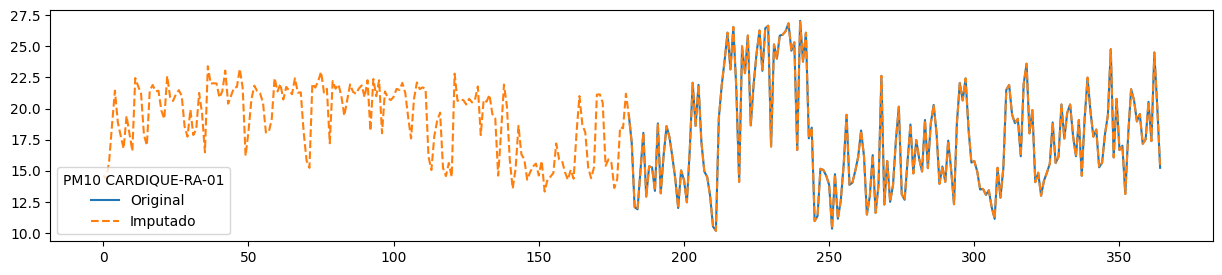

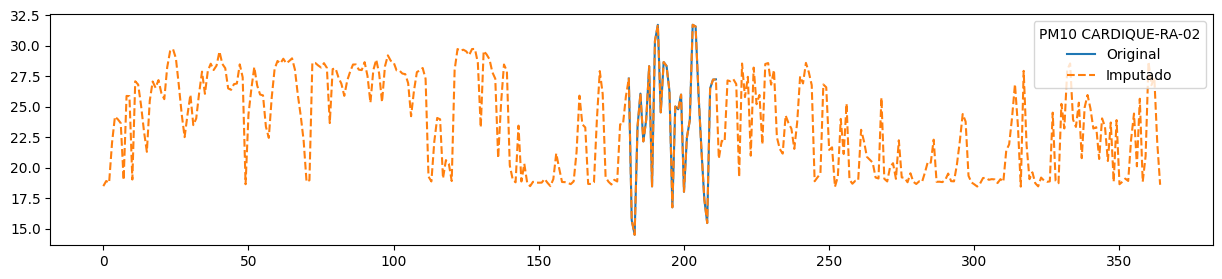

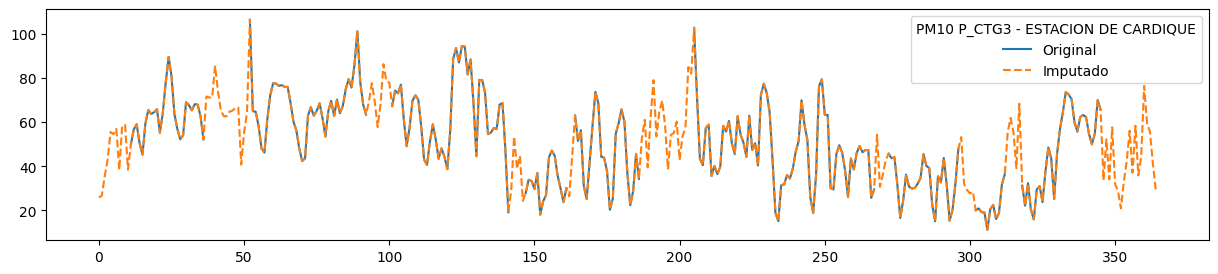

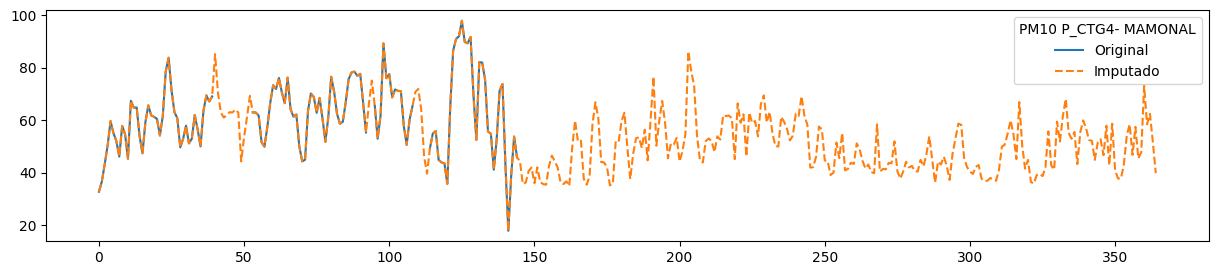

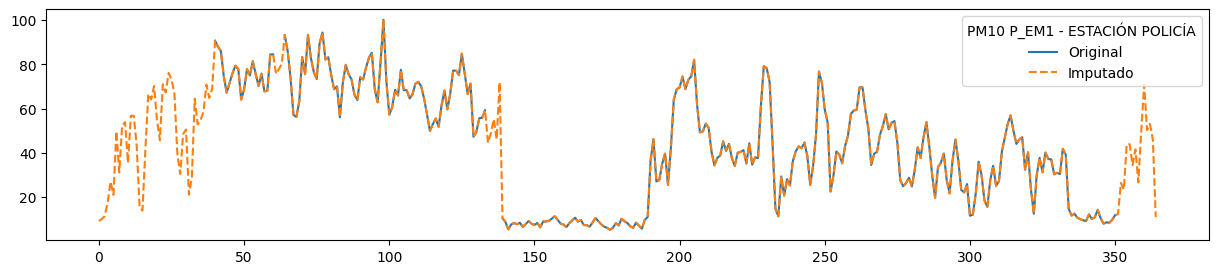

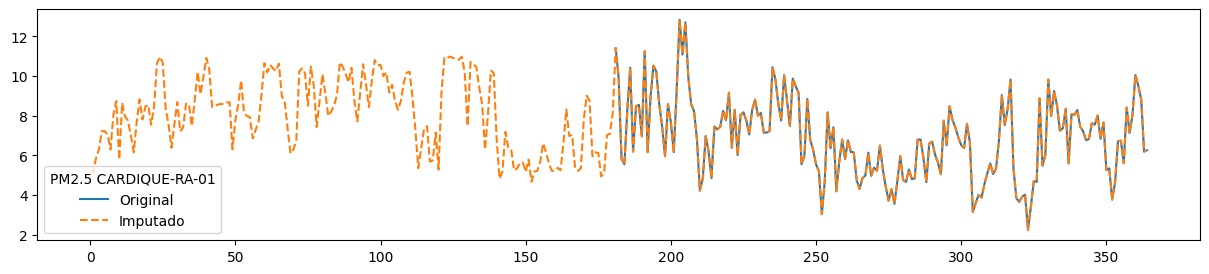

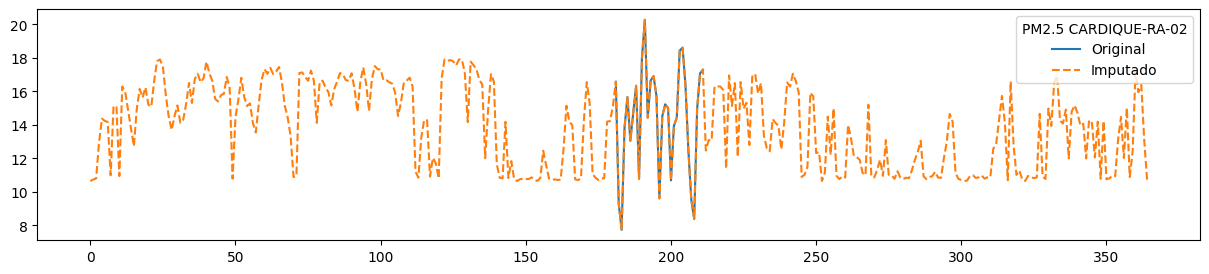

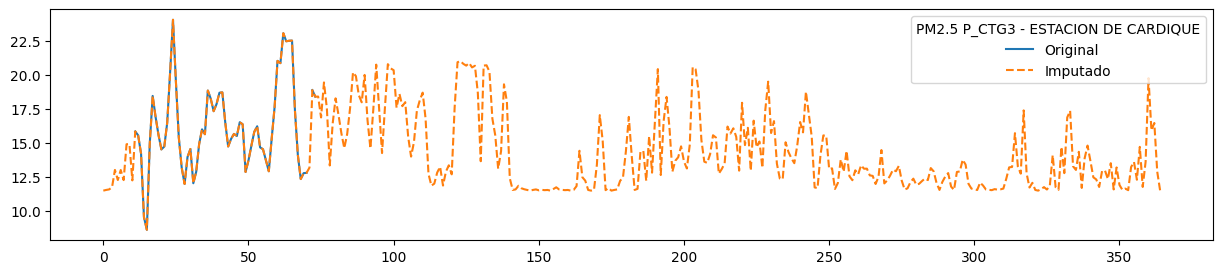

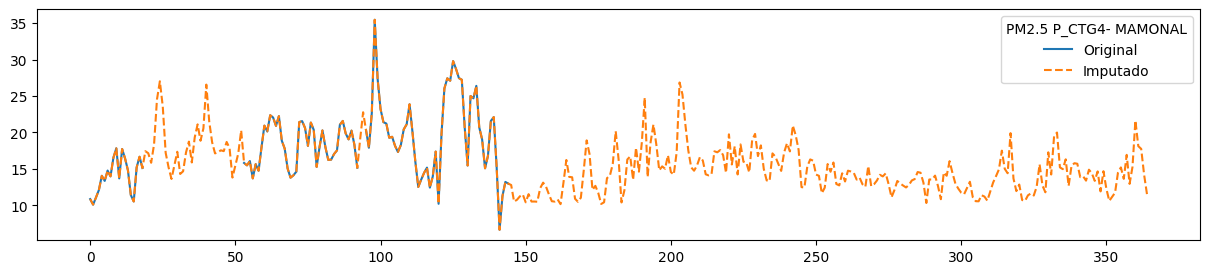

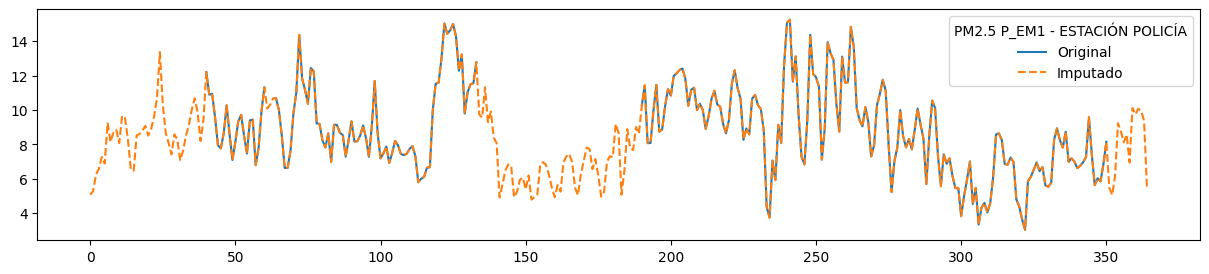

In [ ]:
for i in data.columns[1:]:
  data[i].plot(figsize=(15, 3),label="Original")
  df_final[i].plot(figsize=(15, 3),label="Imputado",linestyle="--")
  plt.legend(title=i);plt.show()

In [ ]:
missing = data.isnull().sum()
percent_missing = (missing / len(data)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': percent_missing})
missing_df = missing_df[missing_df['Faltantes'] > 0]
missing_df.sort_values('Faltantes', ascending=False)




,Faltantes,Porcentaje (%)
PM10 CARDIQUE-RA-02,334,91.506849
PM2.5 CARDIQUE-RA-02,334,91.506849
PM2.5 P_CTG3 - ESTACION DE CARDIQUE,303,83.013699
PM2.5 P_CTG4- MAMONAL,256,70.136986
PM10 P_CTG4- MAMONAL,240,65.753425
PM10 CARDIQUE-RA-01,181,49.589041
PM2.5 CARDIQUE-RA-01,181,49.589041
PM2.5 P_EM1 - ESTACIÓN POLICÍA,113,30.958904
PM10 P_CTG3 - ESTACION DE CARDIQUE,92,25.205479
PM10 P_EM1 - ESTACIÓN POLICÍA,62,16.986301


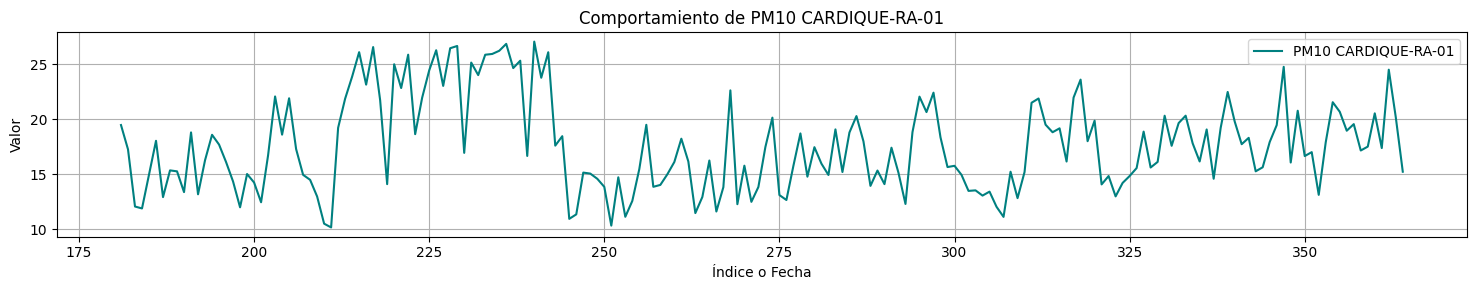

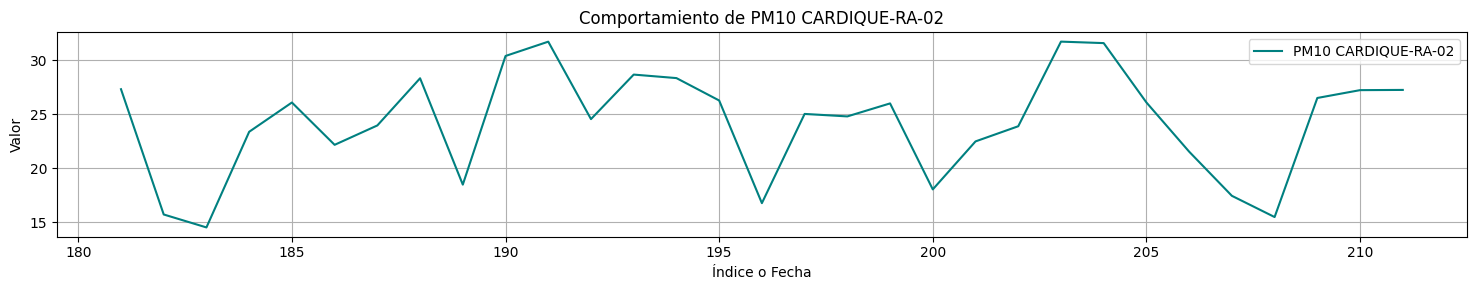

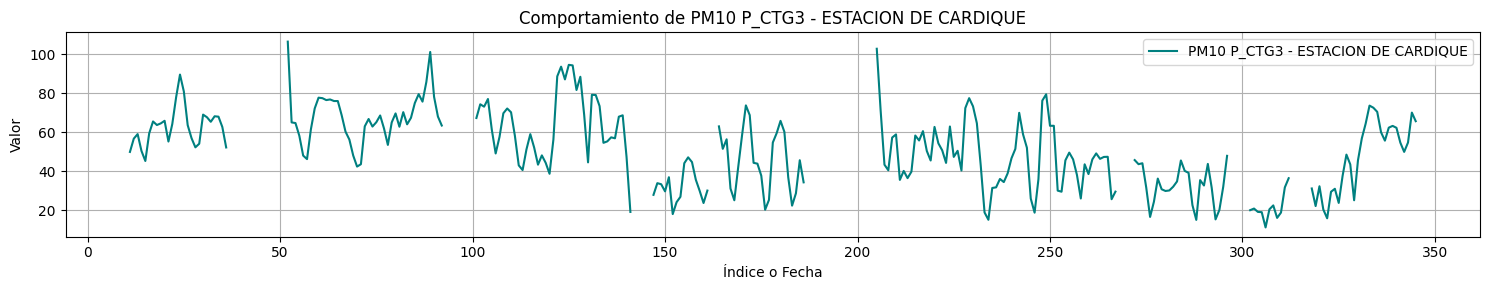

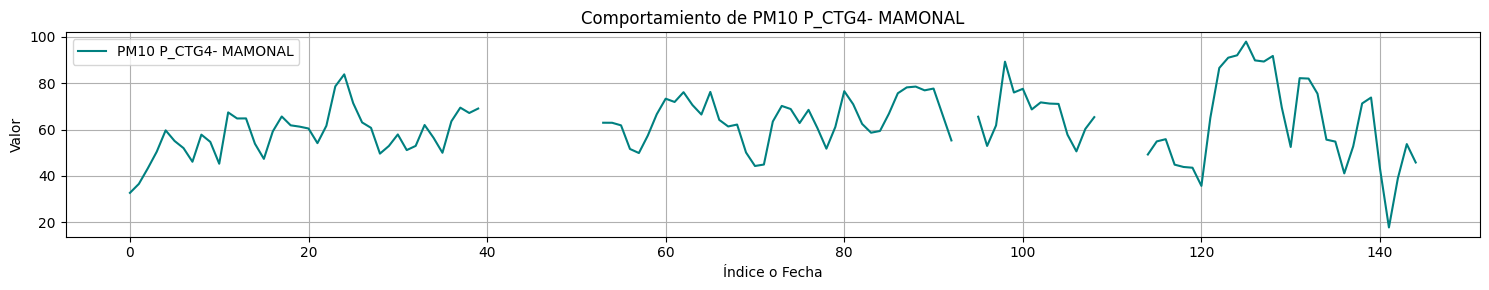

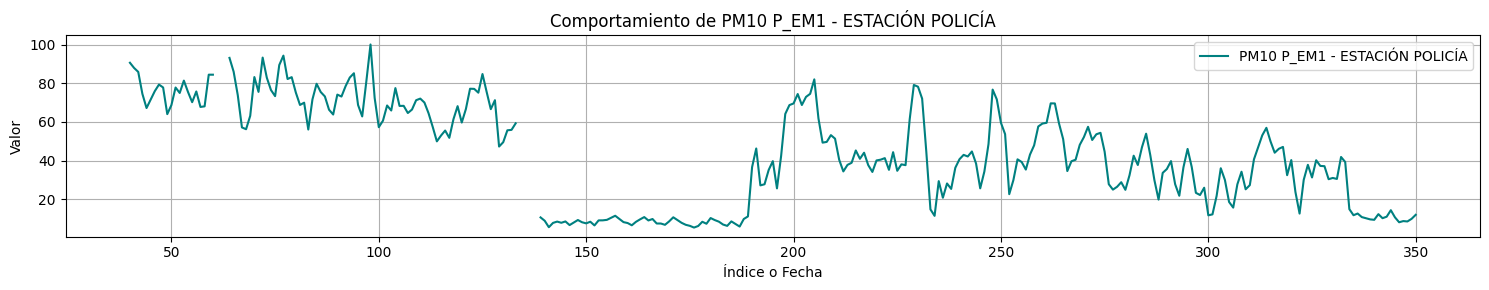

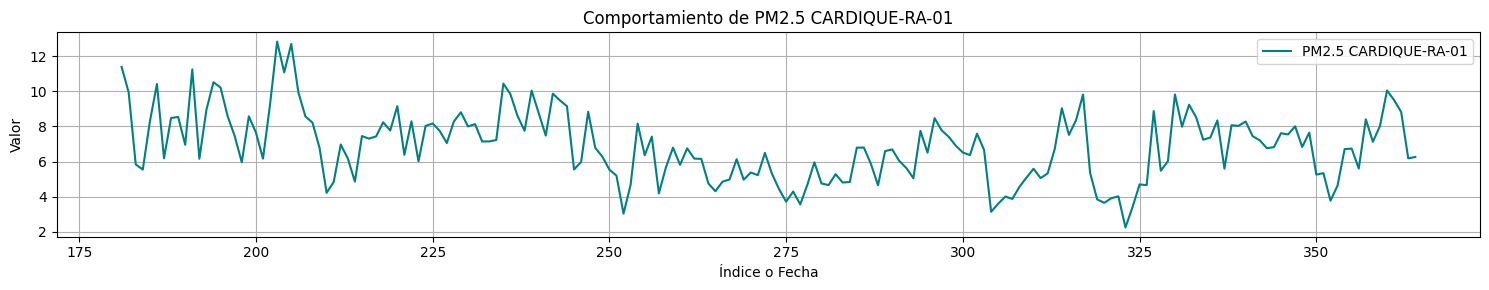

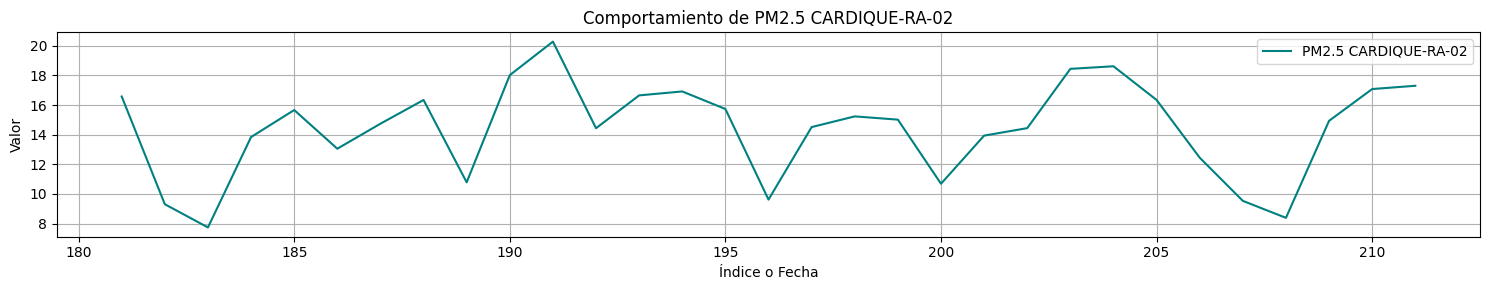

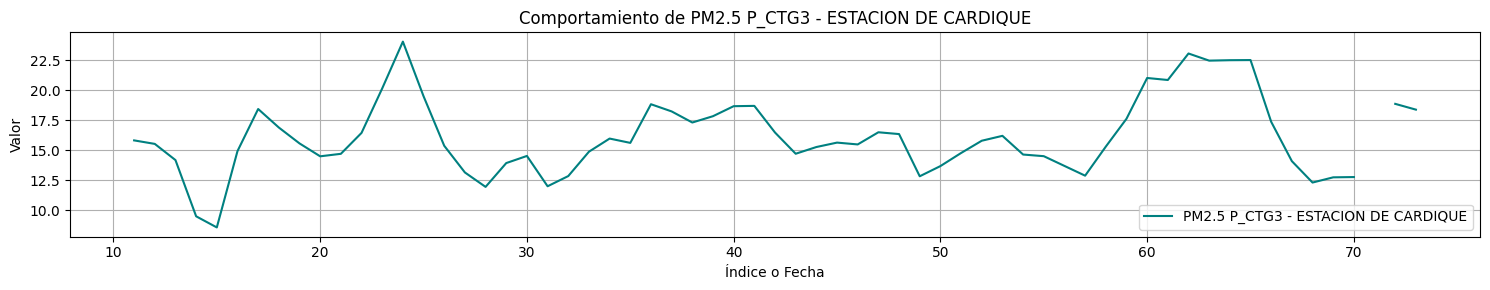

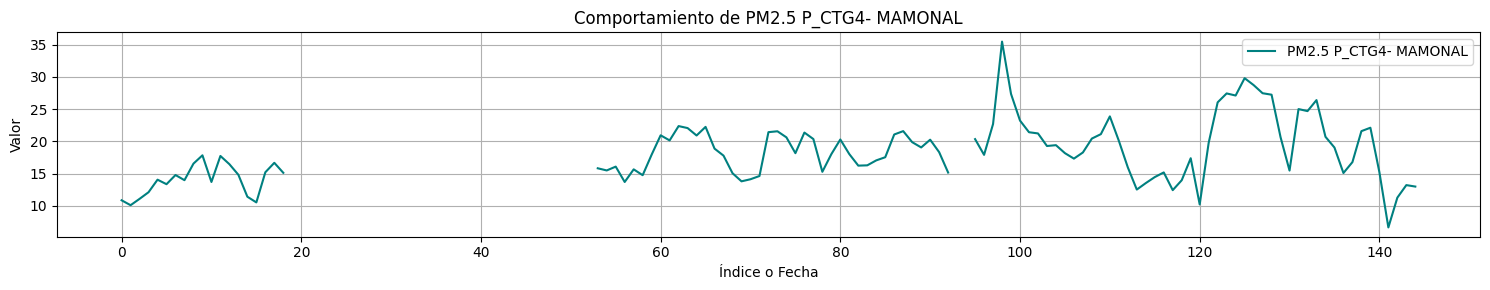

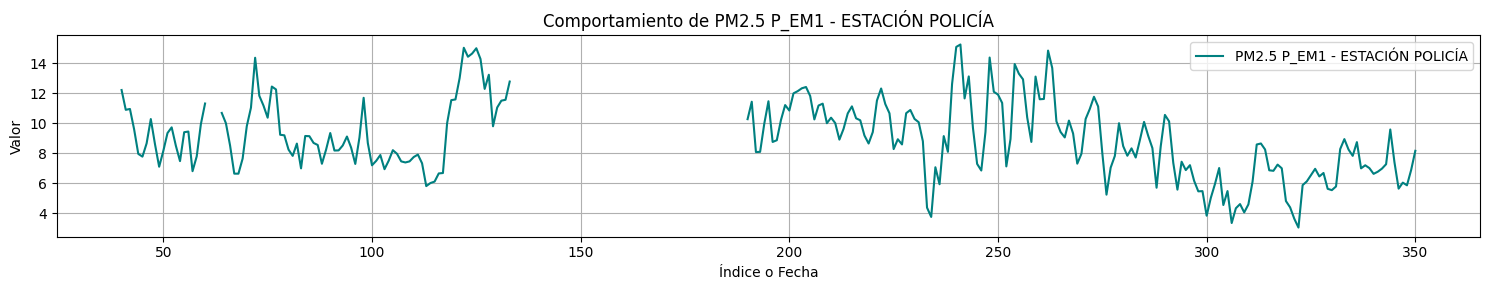

In [ ]:
import matplotlib.pyplot as plt

for i in data.columns[1:]:
    plt.figure(figsize=(15, 3))
    plt.plot(data[i], label=i, color='teal')
    plt.title(f'Comportamiento de {i}')
    plt.xlabel('Índice o Fecha')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


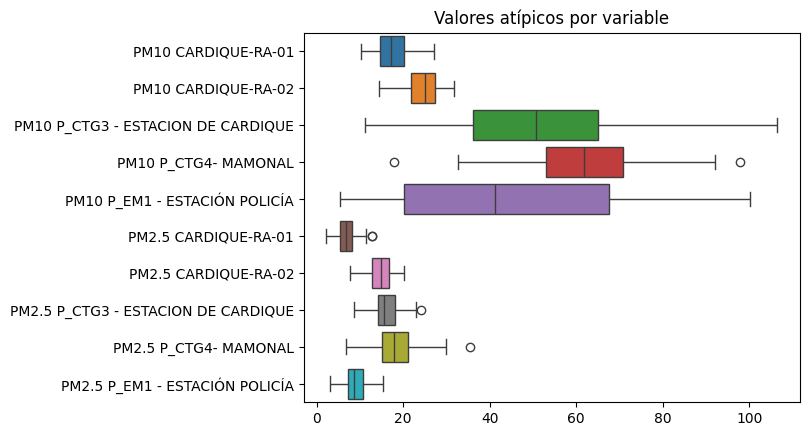

In [ ]:
sns.boxplot(data=data.iloc[:, 1:], orient="h")
plt.title('Valores atípicos por variable')
plt.show()



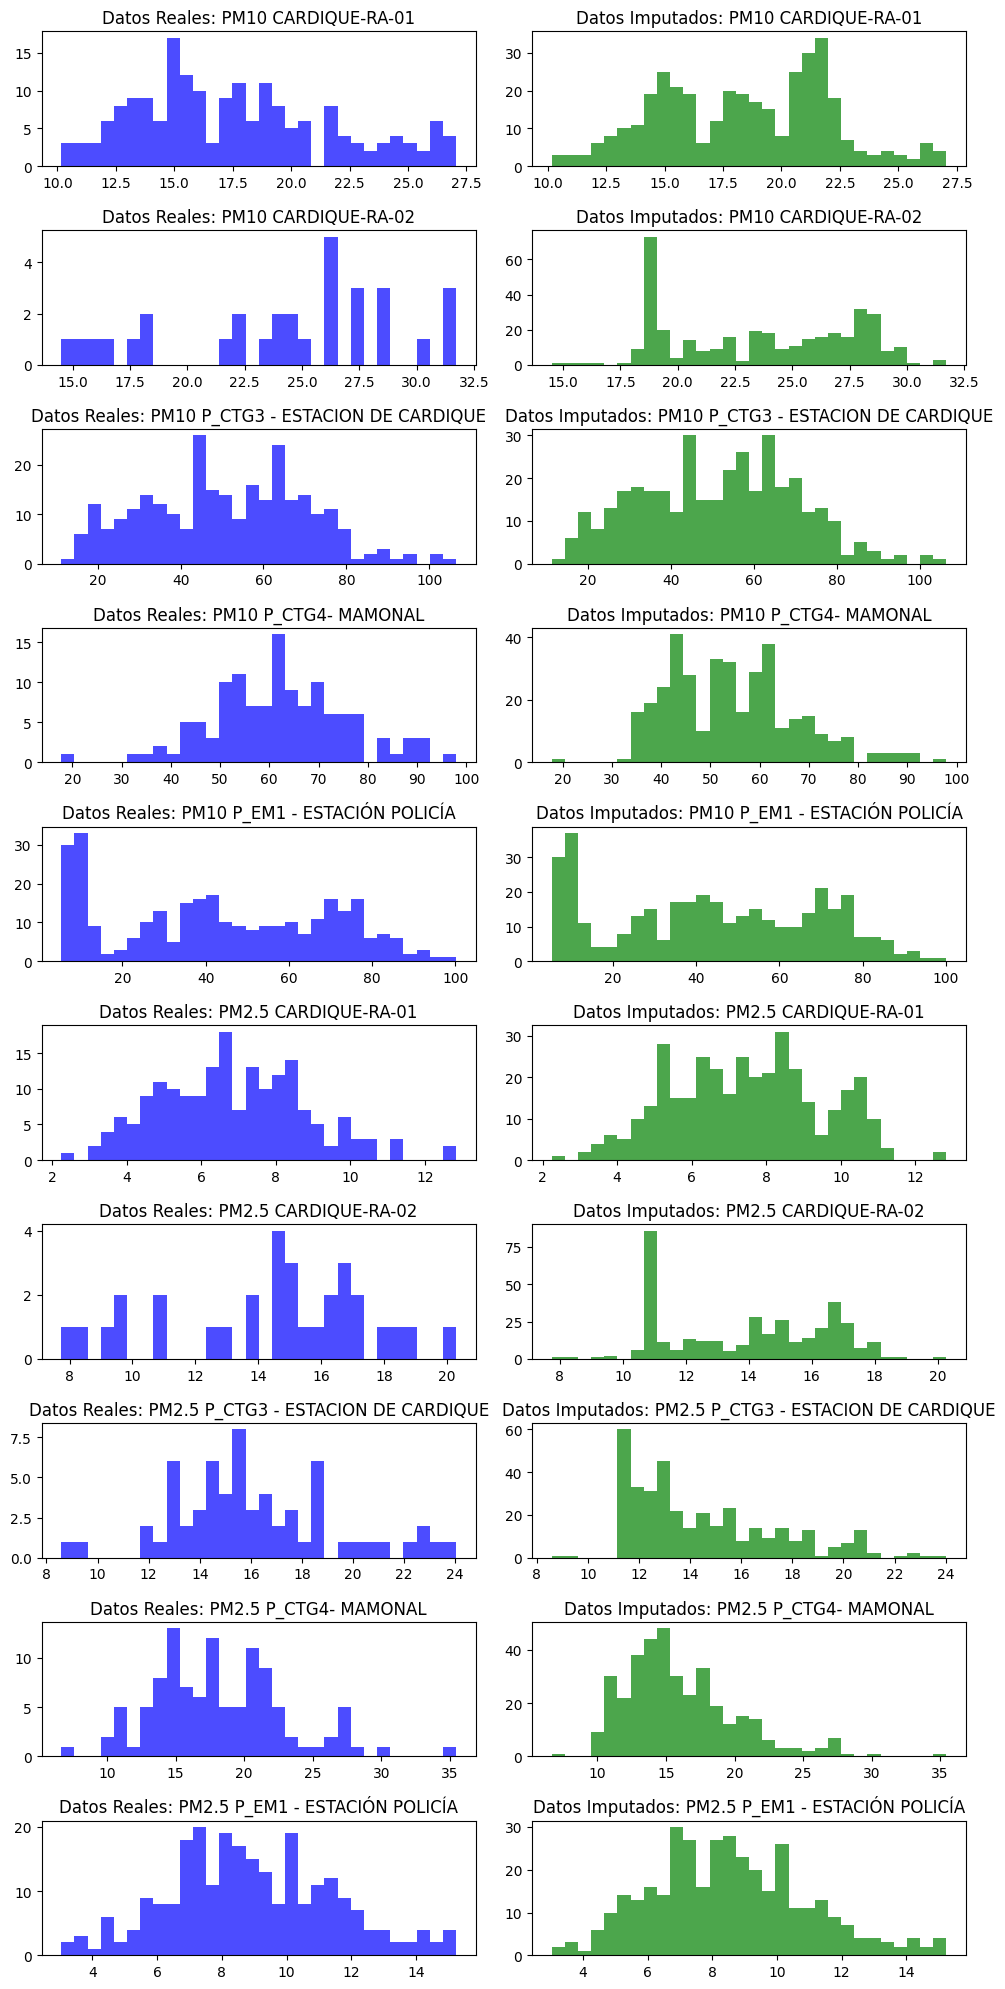

In [ ]:
import matplotlib.pyplot as plt


pm_columns = [
    'PM10 CARDIQUE-RA-01', 'PM10 CARDIQUE-RA-02', 'PM10 P_CTG3 - ESTACION DE CARDIQUE',
    'PM10 P_CTG4- MAMONAL', 'PM10 P_EM1 - ESTACIÓN POLICÍA',
    'PM2.5 CARDIQUE-RA-01', 'PM2.5 CARDIQUE-RA-02', 'PM2.5 P_CTG3 - ESTACION DE CARDIQUE',
    'PM2.5 P_CTG4- MAMONAL', 'PM2.5 P_EM1 - ESTACIÓN POLICÍA'
]


real_data = data[pm_columns]

imputed_data = df_imp_RF[pm_columns].loc[real_data.index]  # Asegurarnos de tomar solo las filas no nulas

fig, axes = plt.subplots(len(pm_columns), 2, figsize=(10, 2 * len(pm_columns)))

for i, col in enumerate(pm_columns):
    axes[i, 0].hist(real_data[col], bins=30, color='blue', alpha=0.7)
    axes[i, 0].set_title(f'Datos Reales: {col}')

    axes[i, 1].hist(imputed_data[col], bins=30, color='green', alpha=0.7)
    axes[i, 1].set_title(f'Datos Imputados: {col}')

plt.tight_layout()
plt.show()


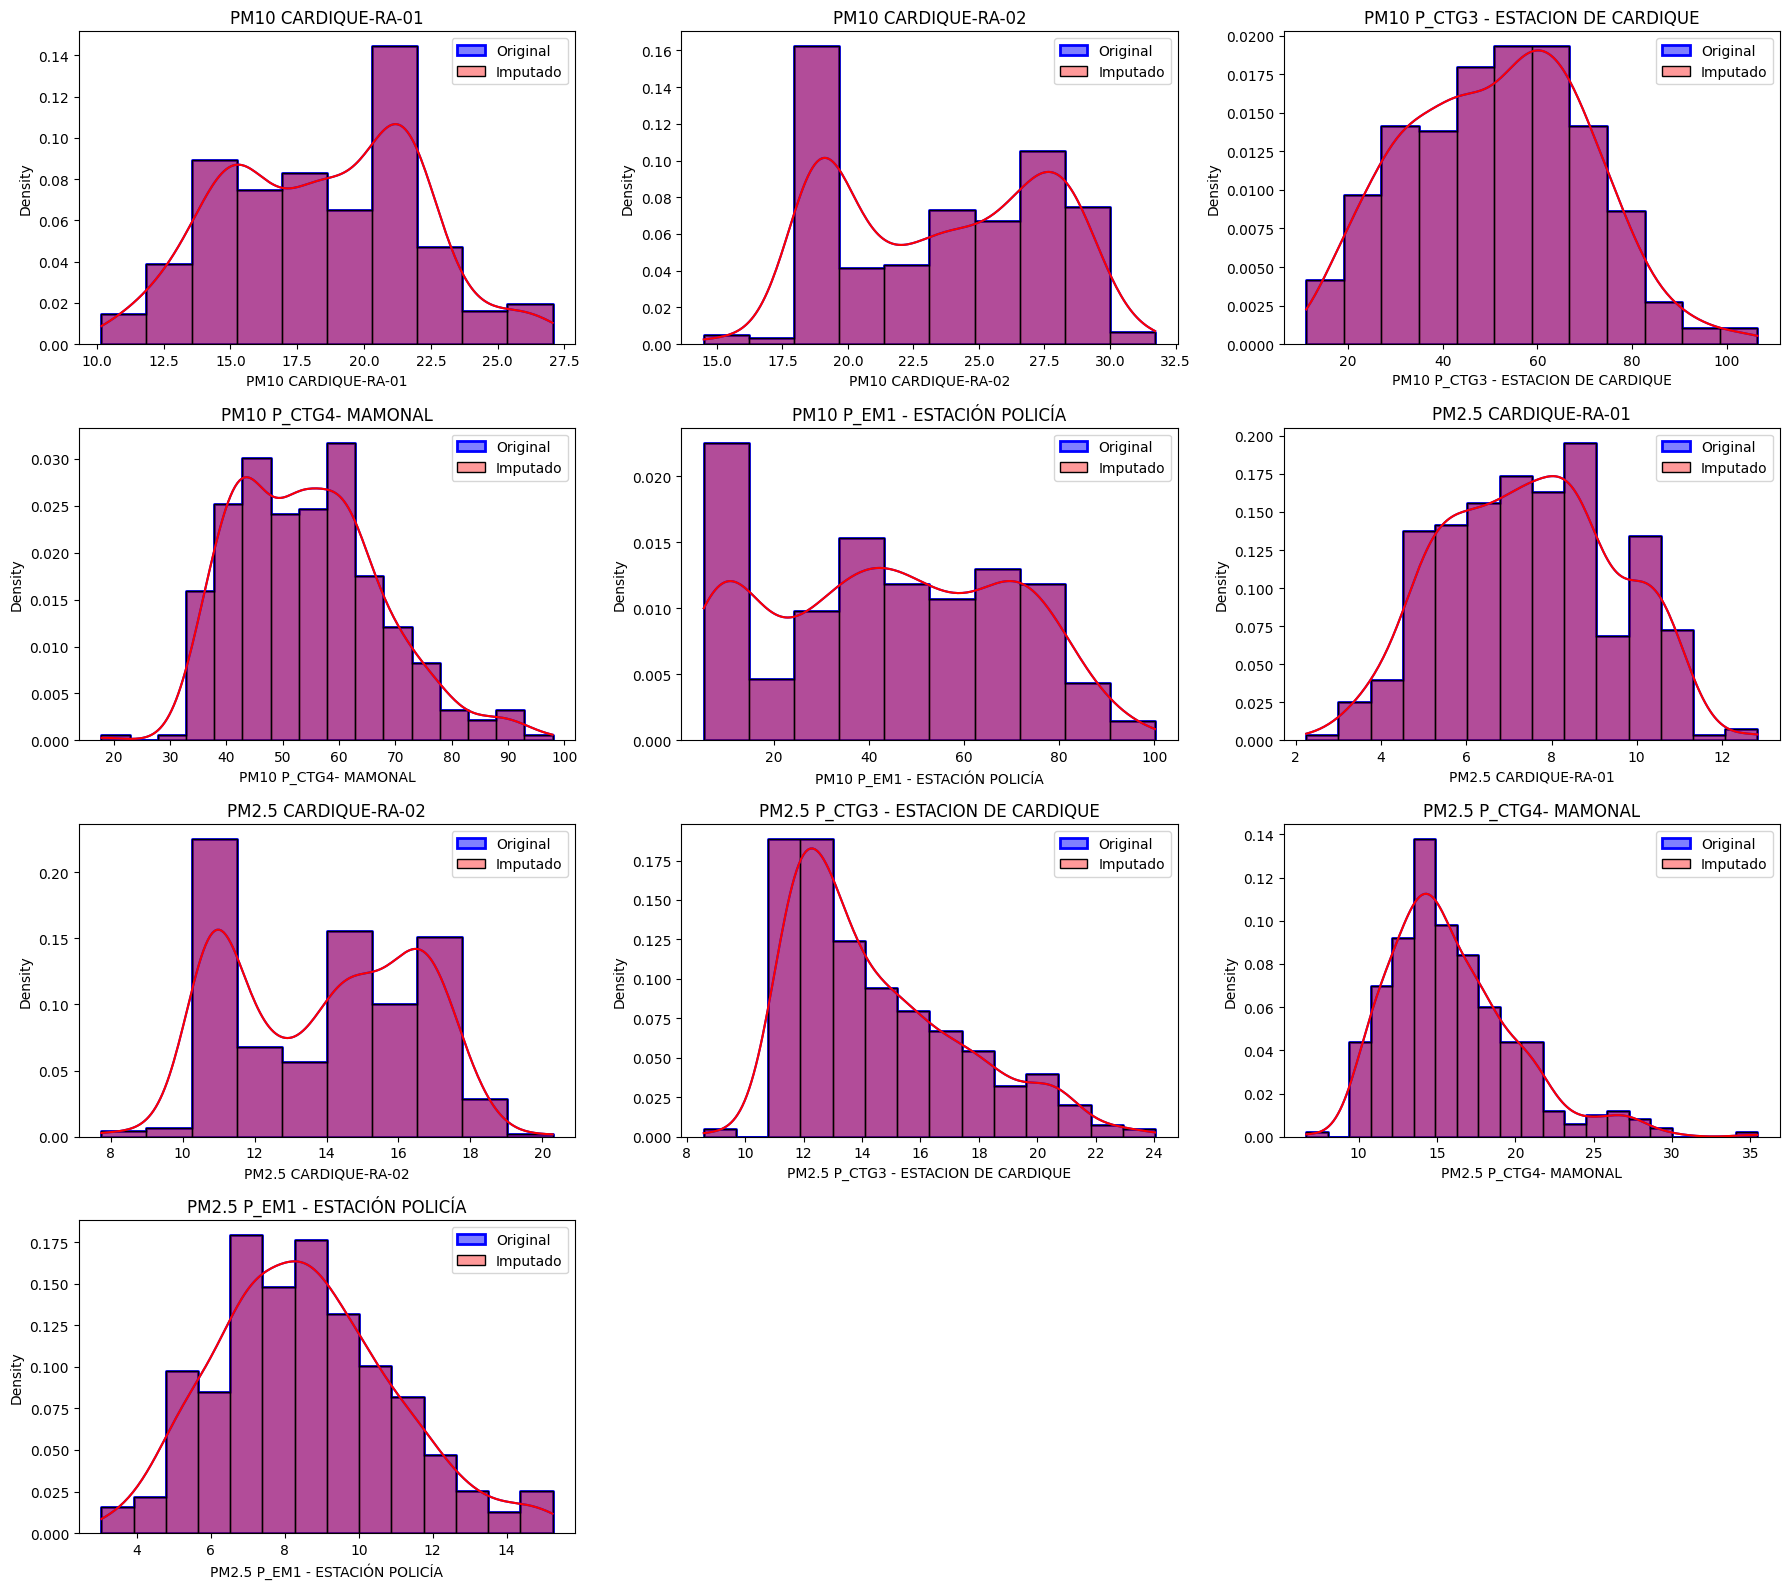

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pm_columns = [
    'PM10 CARDIQUE-RA-01', 'PM10 CARDIQUE-RA-02', 'PM10 P_CTG3 - ESTACION DE CARDIQUE',
    'PM10 P_CTG4- MAMONAL', 'PM10 P_EM1 - ESTACIÓN POLICÍA',
    'PM2.5 CARDIQUE-RA-01', 'PM2.5 CARDIQUE-RA-02', 'PM2.5 P_CTG3 - ESTACION DE CARDIQUE',
    'PM2.5 P_CTG4- MAMONAL', 'PM2.5 P_EM1 - ESTACIÓN POLICÍA'
]

real_data = df_final[pm_columns].dropna()
imputed_data = df_imp_RF[pm_columns].loc[real_data.index]

num_plots = len(pm_columns)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(pm_columns):
    ax = axes[i]

    sns.histplot(real_data[col], kde=True, stat='density', element='step',
                 color='blue', label='Original', ax=ax, linewidth=2)

    sns.histplot(imputed_data[col], kde=True, stat='density', element='bars',
                 color='red', label='Imputado', alpha=0.4, ax=ax)

    ax.set_title(col)
    ax.legend()

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
df_imp_RF.to_excel("datos_imputados_RF.xlsx", index=False)
